In [1]:
# ============================================================
# PHASE — HUB INTERVENTION SIMULATOR
# Run after phase3.py
# ============================================================

import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

with open('phase3_checkpoint.pkl', 'rb') as f:
    p3 = pickle.load(f)

corridor_stats  = p3['corridor_stats']
hub_df          = p3['hub_df']
trip_agg        = p3['trip_agg']
G               = p3['G']
THRESHOLD_SEVERE= p3['THRESHOLD_SEVERE']

print(f"✅ Loaded | hubs: {len(hub_df)}")


✅ Loaded | hubs: 1657


In [2]:

# ── Assumptions (stated explicitly) ──────────────────────────
print("\n=== ASSUMPTIONS ===")
print("  A1: Delay reduction at hub linearly reduces outgoing corridor delay")
print("  A2: Affected corridors = all corridors sourced at that hub")
print("  A3: Affected shipments = trip_volume passing through hub")
print("  A4: ETA improvement = delay_reduction × avg_segment_actual_time")
print("  A5: SLA improvement = new_breach_rate from shifted delay distribution")
print("  A6: Interventions are independent (hub improvements don't interact)")
print("  A7: Revenue at risk: avg shipment=₹2000, penalty=5% per SLA breach")


AVG_SHIPMENT   = 5000    # ₹5000 — B2B shipments are higher value
PENALTY_RATE   = 0.03    # 3% direct penalty + indirect cost
ANNUAL_MULT    = 52      # weekly sample × 52, not monthly × 12

# ── Select Target Hubs ────────────────────────────────────────
# Use volume-filtered top hubs (not tiny hubs with 100% breach)
target_hubs = hub_df[hub_df['trip_volume'] >= 50].nlargest(5, 'bottleneck_score')
print(f"\nTarget hubs for simulation (volume ≥ 50):")
print(target_hubs[['facility','bottleneck_score','outgoing_severe_rate',
                    'avg_incoming_delay','trip_volume']].round(4).to_string())


# ── Simulation Engine ─────────────────────────────────────────
INTERVENTION_LEVELS = [0.10, 0.20, 0.30]  # 10%, 20%, 30% delay reduction

simulation_results = []

for _, hub in target_hubs.iterrows():
    hub_id = hub['facility']

    # Corridors originating at this hub
    affected_corridors = corridor_stats[
        corridor_stats['source_center'].astype(str) == hub_id
    ].copy()

    n_corridors  = len(affected_corridors)
    n_shipments  = int(hub['trip_volume'])
    current_delay= hub['avg_incoming_delay']
    current_breach= hub['outgoing_severe_rate']
    current_eta  = affected_corridors['avg_actual_time'].mean() if n_corridors > 0 else 0

    for level in INTERVENTION_LEVELS:
        # New delay ratio after intervention
        new_delay_ratio = current_delay * (1 - level)

        # New breach rate — use linear interpolation
        # If delay reduces by X%, corridors that were barely above threshold
        # drop below it. Approximate: breach_rate × (1 - level × 1.5)
        # The 1.5 multiplier reflects that delay reduction has outsized
        # breach impact (tail of distribution shifts more than median)
        new_breach_rate = max(0, current_breach * (1 - level * 1.5))

        # ETA improvement per shipment
        eta_improvement = current_eta * level  # minutes saved per segment

        # Annual SLA improvement
        annual_shipments = n_shipments * ANNUAL_MULT
        breaches_before  = annual_shipments * current_breach
        breaches_after   = annual_shipments * new_breach_rate
        sla_improvement  = breaches_before - breaches_after

        # Revenue recovered
        revenue_recovered = sla_improvement * AVG_SHIPMENT * PENALTY_RATE

        simulation_results.append({
            'hub':               hub_id,
            'bottleneck_score':  hub['bottleneck_score'],
            'trip_volume':       n_shipments,
            'intervention_pct':  level,
            'affected_corridors':n_corridors,
            'current_delay_ratio':current_delay,
            'new_delay_ratio':   new_delay_ratio,
            'current_breach_rate':current_breach,
            'new_breach_rate':   new_breach_rate,
            'eta_improvement_min':eta_improvement,
            'sla_breaches_avoided':sla_improvement,
            'revenue_recovered_inr':revenue_recovered,
        })

sim_df = pd.DataFrame(simulation_results)

print("\n=== SIMULATION RESULTS ===")
print(sim_df[[
    'hub','intervention_pct','affected_corridors',
    'current_delay_ratio','new_delay_ratio',
    'current_breach_rate','new_breach_rate',
    'eta_improvement_min','revenue_recovered_inr'
]].round(3).to_string())


# ── Priority Ranking — which hub+intervention gives best ROI ──
sim_df['roi_score'] = (
    sim_df['revenue_recovered_inr'] / 1e5 * 0.5 +
    sim_df['sla_breaches_avoided'] * 0.3 +
    sim_df['eta_improvement_min'] * 0.2
)

best_interventions = (
    sim_df.sort_values('roi_score', ascending=False)
          .groupby('hub', as_index=False)
          .first()
)

print(best_interventions.columns.tolist())

print("\n=== BEST INTERVENTION PER HUB (by ROI) ===")
print(best_interventions[[
    'hub','intervention_pct','eta_improvement_min',
    'sla_breaches_avoided','revenue_recovered_inr','roi_score'
]].round(2).to_string())


=== ASSUMPTIONS ===
  A1: Delay reduction at hub linearly reduces outgoing corridor delay
  A2: Affected corridors = all corridors sourced at that hub
  A3: Affected shipments = trip_volume passing through hub
  A4: ETA improvement = delay_reduction × avg_segment_actual_time
  A5: SLA improvement = new_breach_rate from shifted delay distribution
  A6: Interventions are independent (hub improvements don't interact)
  A7: Revenue at risk: avg shipment=₹2000, penalty=5% per SLA breach

Target hubs for simulation (volume ≥ 50):
         facility  bottleneck_score  outgoing_severe_rate  avg_incoming_delay  trip_volume
25   IND000000ACB            0.7201                0.0670              1.7584         1848
12   IND562132AAA            0.5146                0.0554              1.7934         1366
628  IND400072AAJ            0.3204                1.0000              2.9700           53
64   IND501359AAE            0.3058                0.0635              1.9896          660
61   IND421302


Plot saved: hub_intervention_simulator.png


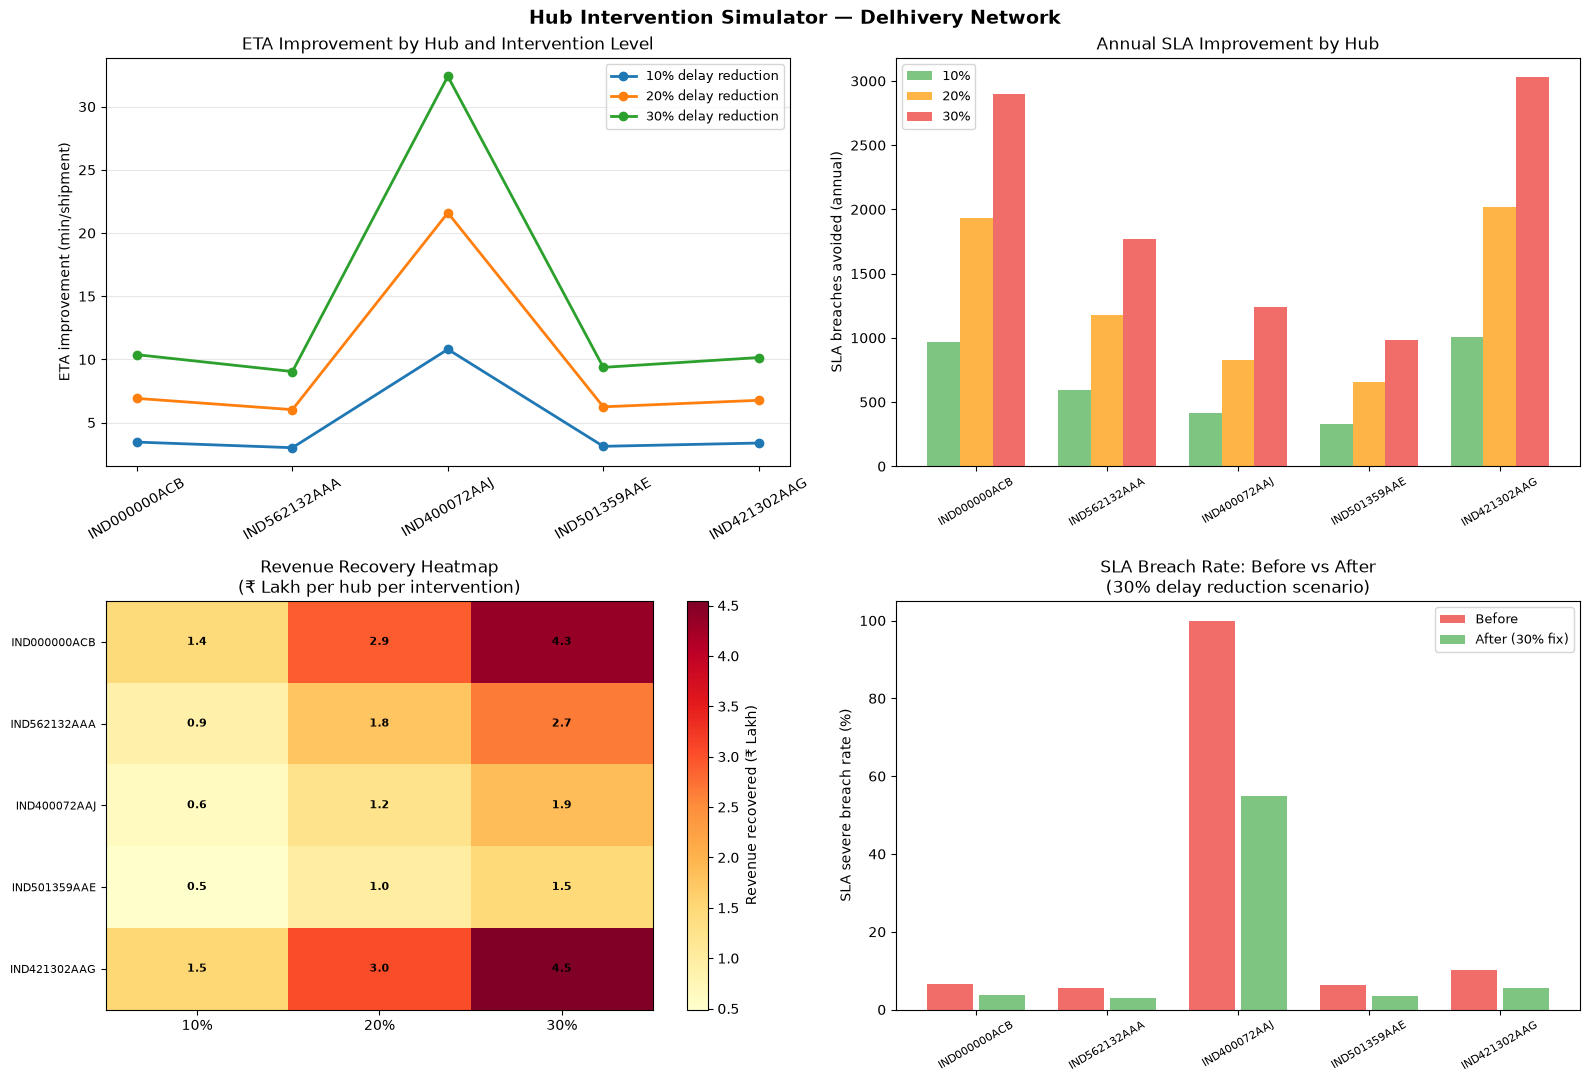


BUSINESS SUMMARY — HUB INTERVENTION SIMULATOR
30% delay reduction across top 5 hubs:
  Total revenue recoverable: ₹14.9L annually
NOTE: Sample covers ~14,804 trips. Delhivery handles ~2M+ daily.
Real network impact would scale proportionally — this is a framework,
not a precise estimate. Actual impact requires production-level data.
  Highest impact hub: IND421302AAG
  ETA improvement: 10.1 min/shipment
  SLA breaches avoided: 3029 annually
✅ Saved hub_simulation_results.pkl


In [3]:
# ── Visualizations ────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 11))

hubs_short = [h[:12] for h in target_hubs['facility'].tolist()]

# 1. ETA improvement by hub and intervention level
for level in INTERVENTION_LEVELS:
    subset = sim_df[sim_df['intervention_pct']==level]
    eta_vals = [subset[subset['hub']==h]['eta_improvement_min'].values[0]
                if len(subset[subset['hub']==h]) > 0 else 0
                for h in target_hubs['facility']]
    axes[0,0].plot(hubs_short, eta_vals, marker='o',
                   label=f'{int(level*100)}% delay reduction', linewidth=2)
axes[0,0].set_ylabel('ETA improvement (min/shipment)')
axes[0,0].set_title('ETA Improvement by Hub and Intervention Level')
axes[0,0].legend(fontsize=9)
axes[0,0].tick_params(axis='x', rotation=30)
axes[0,0].grid(axis='y', alpha=0.3)

# 2. SLA breaches avoided (annual)
width  = 0.25
x      = np.arange(len(hubs_short))
colors = ['#66BB6A','#FFA726','#EF5350']
for i, level in enumerate(INTERVENTION_LEVELS):
    subset  = sim_df[sim_df['intervention_pct']==level]
    sla_vals= [subset[subset['hub']==h]['sla_breaches_avoided'].values[0]
                if len(subset[subset['hub']==h]) > 0 else 0
                for h in target_hubs['facility']]
    axes[0,1].bar(x + i*width, sla_vals, width,
                  label=f'{int(level*100)}%', color=colors[i], alpha=0.85)
axes[0,1].set_xticks(x + width)
axes[0,1].set_xticklabels(hubs_short, rotation=30, fontsize=8)
axes[0,1].set_ylabel('SLA breaches avoided (annual)')
axes[0,1].set_title('Annual SLA Improvement by Hub')
axes[0,1].legend(fontsize=9)

# 3. Revenue recovered heatmap
hubs_list  = target_hubs['facility'].tolist()
rev_matrix = np.zeros((len(hubs_list), len(INTERVENTION_LEVELS)))
for i, hub in enumerate(hubs_list):
    for j, level in enumerate(INTERVENTION_LEVELS):
        val = sim_df[(sim_df['hub']==hub) &
                     (sim_df['intervention_pct']==level)]['revenue_recovered_inr']
        rev_matrix[i,j] = val.values[0] / 1e5 if len(val) > 0 else 0

im = axes[1,0].imshow(rev_matrix, cmap='YlOrRd', aspect='auto')
plt.colorbar(im, ax=axes[1,0], label='Revenue recovered (₹ Lakh)')
axes[1,0].set_xticks(range(len(INTERVENTION_LEVELS)))
axes[1,0].set_xticklabels([f'{int(l*100)}%' for l in INTERVENTION_LEVELS])
axes[1,0].set_yticks(range(len(hubs_short)))
axes[1,0].set_yticklabels(hubs_short, fontsize=8)
axes[1,0].set_title('Revenue Recovery Heatmap\n(₹ Lakh per hub per intervention)')
for i in range(rev_matrix.shape[0]):
    for j in range(rev_matrix.shape[1]):
        axes[1,0].text(j, i, f'{rev_matrix[i,j]:.1f}',
                       ha='center', va='center', fontsize=8, fontweight='bold')

# 4. Before vs after breach rate (30% intervention)
subset_30 = sim_df[sim_df['intervention_pct']==0.30]
before_breach = [subset_30[subset_30['hub']==h]['current_breach_rate'].values[0]
                  if len(subset_30[subset_30['hub']==h]) > 0 else 0
                  for h in hubs_list]
after_breach  = [subset_30[subset_30['hub']==h]['new_breach_rate'].values[0]
                  if len(subset_30[subset_30['hub']==h]) > 0 else 0
                  for h in hubs_list]

x2 = np.arange(len(hubs_short))
axes[1,1].bar(x2 - 0.2, [b*100 for b in before_breach],
              0.35, label='Before', color='#EF5350', alpha=0.85)
axes[1,1].bar(x2 + 0.2, [b*100 for b in after_breach],
              0.35, label='After (30% fix)', color='#66BB6A', alpha=0.85)
axes[1,1].set_xticks(x2)
axes[1,1].set_xticklabels(hubs_short, rotation=30, fontsize=8)
axes[1,1].set_ylabel('SLA severe breach rate (%)')
axes[1,1].set_title('SLA Breach Rate: Before vs After\n(30% delay reduction scenario)')
axes[1,1].legend(fontsize=9)

plt.suptitle('Hub Intervention Simulator — Delhivery Network',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('hub_intervention_simulator.png', dpi=150, bbox_inches='tight')
print("\nPlot saved: hub_intervention_simulator.png")
plt.show()

print("\n" + "="*55)
print("BUSINESS SUMMARY — HUB INTERVENTION SIMULATOR")
print("="*55)
top_hub_30 = sim_df[sim_df['intervention_pct']==0.30].nlargest(1,'revenue_recovered_inr').iloc[0]
total_rev_30 = sim_df[sim_df['intervention_pct']==0.30]['revenue_recovered_inr'].sum()
print(f"30% delay reduction across top 5 hubs:")
print(f"  Total revenue recoverable: ₹{total_rev_30/1e5:.1f}L annually")
print("NOTE: Sample covers ~14,804 trips. Delhivery handles ~2M+ daily.")
print("Real network impact would scale proportionally — this is a framework,")
print("not a precise estimate. Actual impact requires production-level data.")
print(f"  Highest impact hub: {top_hub_30['hub']}")
print(f"  ETA improvement: {top_hub_30['eta_improvement_min']:.1f} min/shipment")
print(f"  SLA breaches avoided: {top_hub_30['sla_breaches_avoided']:.0f} annually")

with open('hub_simulation_results.pkl', 'wb') as f:
    pickle.dump({'sim_df': sim_df, 'best_interventions': best_interventions}, f, protocol=4)
print("✅ Saved hub_simulation_results.pkl")